# Quantum Support Vector Machines

In this notebook, we will use quantum circuits to compute a kernel that we will later use in a classical SVM. We will use Qiskit's implementation, that already encapsulates the kernel matrix computation and the SVM training.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

We will start with a very simple example that is clearly linearly separable.

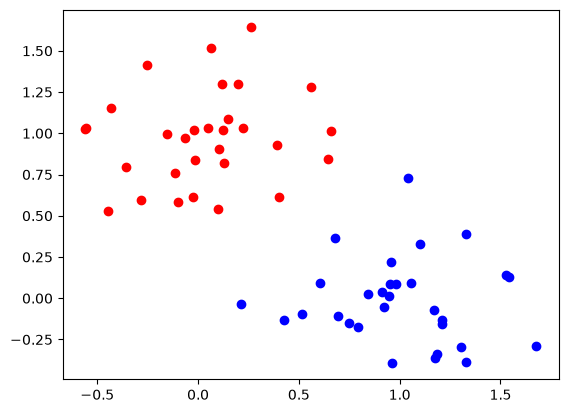

In [2]:
np.random.seed(2020)
n = 30

# Training examples for class 0

mean = [0, 1]
cov = [[0.1, 0], [0, 0.1]]

A = (np.random.multivariate_normal(mean, cov, n))
x_A, y_A = A.T
plt.plot(x_A, y_A, 'ro');

# Training examples for class 1

mean = [1, 0]
cov = [[0.1, 0], [0, 0.1]]

B = (np.random.multivariate_normal(mean, cov, n))
x_B, y_B = B.T
plt.plot(x_B, y_B, 'bo');

To encode the data, we will use a ZZ feature map in dimension 2 with linear entanglement.

In [3]:
feature_map = zz_feature_map(feature_dimension=2, reps=2, entanglement='linear')
feature_map.draw()

┌───┐┌───────────┐                                          ┌───┐»
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐├───┤»
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├┤ H ├»
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘└───┘»
«   ┌───────────┐                                          
«0: ┤ P(2*x[0]) ├──■────────────────────────────────────■──
«   ├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
«1: ┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
«   └───────────┘└───┘└──────────────────────────────┘└───┘

After we have generated the training data and defined the feature map, we can now train the QSVC. 

In [5]:
training_input = np.append(A,B,axis =0)
training_labels = np.array([0]*n+[1]*n) # Training labels are 0 and 1 

quantum_kernel = FidelityStatevectorKernel(feature_map=feature_map)
qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(training_input, training_labels)

To test the performance, we are going to generate test data according to the same distributions used for training.

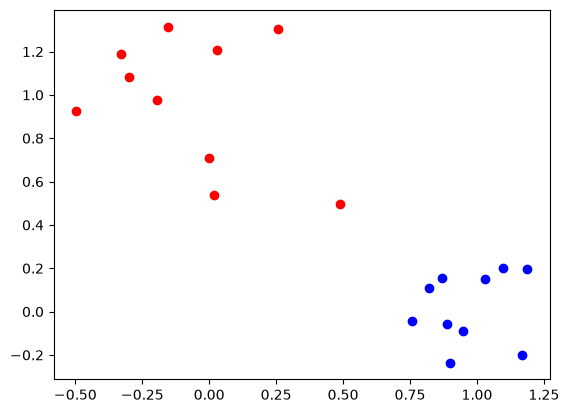

In [6]:
n = 10

# Test examples for class 0

mean = [0, 1]
cov = [[0.1, 0], [0, 0.1]]

C = (np.random.multivariate_normal(mean, cov, n))
x_C, y_C = C.T
plt.plot(x_C, y_C, 'ro');

# Test examples for class 1

mean = [1, 0]
cov = [[0.05, 0], [0, 0.05]]

D = (np.random.multivariate_normal(mean, cov, n))
x_D, y_D = D.T
plt.plot(x_D, y_D, 'bo');


We now use the trained QSVC to predict the class of the test examples. We can also compute the accuracy directly if we provide the labels. 

In [7]:
print("Prediction for examples in test class 0", qsvc.predict(C))
print("Prediction for examples in test class 1", qsvc.predict(D))

test_input = np.append(C,D,axis =0)
test_labels = np.array([0]*n+[1]*n)

print("Accuracy", qsvc.score(test_input, test_labels))

Prediction for examples in test class 0 [0 0 0 0 0 0 0 0 0 0]
Prediction for examples in test class 1 [0 0 1 1 1 1 1 1 1 1]
Accuracy 0.9


We can also use the breast-cancer dataset from scikit-learn.

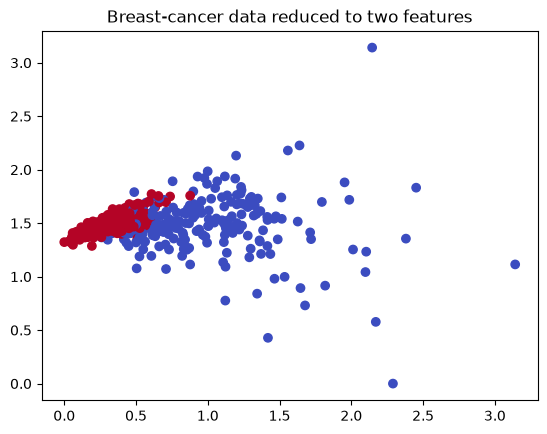

In [9]:
dataset = load_breast_cancer()
features = PCA(n_components=2).fit_transform(dataset.data)
features = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(features)

training_input, test_input, training_labels, test_labels = train_test_split(
    features,
    dataset.target,
    train_size=200,
    test_size=20,
    stratify=dataset.target,
    random_state=2020,
)

plt.scatter(features[:, 0], features[:, 1], c=dataset.target, cmap="coolwarm")
plt.title("Breast-cancer data reduced to two features");

We first use a simple feature map

In [10]:
feature_map = zz_feature_map(feature_dimension=2, reps=1, entanglement='linear')
feature_map.draw()

┌───┐┌───────────┐                                          
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘

In [11]:
quantum_kernel = FidelityStatevectorKernel(feature_map=feature_map)
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(training_input, training_labels)

print("Accuracy: ", qsvc.score(test_input, test_labels))

Accuracy:  0.95


We now use a more sophisticated feature map

In [12]:
feature_map = zz_feature_map(feature_dimension=2, reps=2, entanglement='linear')
feature_map.draw()

┌───┐┌───────────┐                                          ┌───┐»
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐├───┤»
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├┤ H ├»
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘└───┘»
«   ┌───────────┐                                          
«0: ┤ P(2*x[0]) ├──■────────────────────────────────────■──
«   ├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
«1: ┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
«   └───────────┘└───┘└──────────────────────────────┘└───┘

In [13]:
quantum_kernel = FidelityStatevectorKernel(feature_map=feature_map)
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(training_input, training_labels)

print("Accuracy: ", qsvc.score(test_input, test_labels))

Accuracy:  1.0
